## Data


In [5]:
from poe import PortfolioOptimizationEnv
from utils import Utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stockstats import wrap

# For not having unwanted errors
plt.rcParams["font.family"] = "DejaVu Sans"

In [6]:
df = pd.read_csv('./data/features_panel.csv')
df.info()
df = wrap(df)

<class 'pandas.DataFrame'>
RangeIndex: 250100 entries, 0 to 250099
Data columns (total 32 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              250100 non-null  str    
 1   tic               250100 non-null  str    
 2   close             250100 non-null  float64
 3   volume            250100 non-null  int64  
 4   rsi_6             250100 non-null  float64
 5   stochrsi_3        250100 non-null  float64
 6   boll_ub           250100 non-null  float64
 7   boll_lb           250100 non-null  float64
 8   boll_pctb         250100 non-null  float64
 9   volume_stad       250100 non-null  float64
 10  rsi_6_scale       250100 non-null  float64
 11  stochrsi_3_scale  250100 non-null  float64
 12  macd_stad         250100 non-null  float64
 13  macds_stad        250100 non-null  float64
 14  tema_stad         250100 non-null  float64
 15  pvo_stad          250100 non-null  float64
 16  pvos_stad         250100 non-nu

In [7]:
features = df.copy()
features = features.reset_index()
features.info()


<class 'stockstats.StockDataFrame'>
RangeIndex: 250100 entries, 0 to 250099
Data columns (total 32 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              250100 non-null  str    
 1   tic               250100 non-null  str    
 2   close             250100 non-null  float64
 3   volume            250100 non-null  int64  
 4   rsi_6             250100 non-null  float64
 5   stochrsi_3        250100 non-null  float64
 6   boll_ub           250100 non-null  float64
 7   boll_lb           250100 non-null  float64
 8   boll_pctb         250100 non-null  float64
 9   volume_stad       250100 non-null  float64
 10  rsi_6_scale       250100 non-null  float64
 11  stochrsi_3_scale  250100 non-null  float64
 12  macd_stad         250100 non-null  float64
 13  macds_stad        250100 non-null  float64
 14  tema_stad         250100 non-null  float64
 15  pvo_stad          250100 non-null  float64
 16  pvos_stad         2501

In [8]:
TRAIN_WINDOW = 1000 # sessions
TEST_WINDOW = 200 # sessions

train, test = Utils.train_test_split(features, TRAIN_WINDOW, TEST_WINDOW)
test.reset_index(inplace=True, drop=True)
train.reset_index(inplace=True, drop=True)

In [9]:
train.dropna(inplace=True)
train.columns

Index(['date', 'tic', 'close', 'volume', 'rsi_6', 'stochrsi_3', 'boll_ub',
       'boll_lb', 'boll_pctb', 'volume_stad', 'rsi_6_scale',
       'stochrsi_3_scale', 'macd_stad', 'macds_stad', 'tema_stad', 'pvo_stad',
       'pvos_stad', 'pvoh_stad', 'log-ret_stad', 'adx_scale', 'pdi_scale',
       'ndi_scale', 'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal',
       'boll_signal', 'macd_signal_held', 'rsi_signal_held', 'adx_signal_held',
       'cci_signal_held', 'boll_signal_held'],
      dtype='str')

In [10]:
FEATURE_LIST = [
    "boll_pctb",          # close within its Bollinger band (replaces raw close)
    "volume_stad",        # 10-day z-score of volume (replaces raw volume)
    "rsi_6_scale",        # rsi_6 / 100
    "macd_stad",
    "macds_stad",
    "adx_scale",
    "pvo_stad",
    "tema_stad",
    "stochrsi_3_scale",   # stochrsi_3 / 100
    "log-ret_stad",
]

In [11]:
# Tuning setup: tune on a 25-asset subset, then retrain the best settings once on all assets
TUNE_N_ASSETS = 25
TOTAL_TIMESTEPS = 20_000   # per Optuna trial and for the final retrain
N_TRIALS = 5

tune_tics = sorted(train["tic"].unique())[:TUNE_N_ASSETS]
tune_train = train[train["tic"].isin(tune_tics)].reset_index(drop=True)
print(f"tuning on {tune_train['tic'].nunique()} of {train['tic'].nunique()} assets, "
      f"{tune_train['date'].nunique()} sessions")

ACTION_TEMPERATURE = 5   # softmax sharpness; with 100 assets the largest single weight goes from 2.65% to ~60%
EW_PENALTY = 1e-4        # daily reward penalty at exactly equal weight, 0 with everything in one asset

def make_env(df, **kwargs):
    """Portfolio env with the notebook's standard settings; keyword arguments override them."""
    settings = dict(
        df=df,
        initial_amount=10000,
        order_df=True,
        comission_fee_pct=0.001,
        comission_fee_model="trf",
        features=FEATURE_LIST,
        return_last_action=True,
        normalize_df=None,
        action_temperature=ACTION_TEMPERATURE,
    )
    settings.update(kwargs)
    return PortfolioOptimizationEnv(**settings)  # type: ignore[arg-type]

tuning on 25 of 100 assets, 1000 sessions


In [12]:
env = PortfolioOptimizationEnv(
    df = features,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features = FEATURE_LIST,
)

Normalizing ['boll_pctb', 'volume_stad', 'rsi_6_scale', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3_scale', 'log-ret_stad'] by previous time...


## Equal-weight portfolio


In [13]:
# Equal Weight Portfolio
def equal_weight_portfolio(env):
    n = env._stock_dim
    weights = np.zeros(n + 1, dtype=np.float32)
    weights[1:] = 1/n
    weights /= weights.sum()
    rewards = []

    while True:
        obs, reward, terminated, truncated, info = env.step(weights)
        rewards.append(reward)
        if terminated:
            break
    
    return rewards

In [14]:
ew_train_env = make_env(train)

In [15]:
equal_weight_portfolio_rewards = equal_weight_portfolio(ew_train_env)


Initial portfolio value:10000
Final portfolio value: 24291.064453125
Final accumulative portfolio value: 2.4291064739227295
Maximum DrawDown: -0.18307952064911415
Sharpe ratio: 1.789689423750154
Mean ex-ante daily vol: 0.007337166822174014
Mean deviation from equal weight: 1.2982072251164414e-07


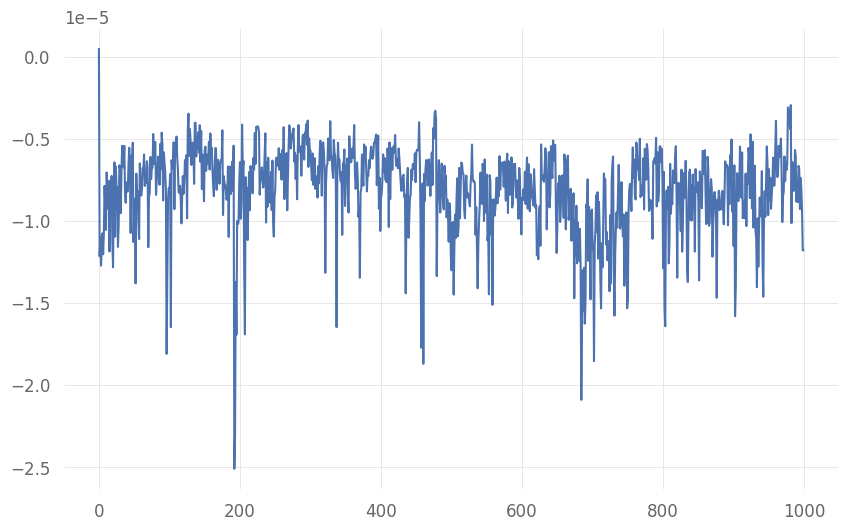

In [16]:
plt.plot(equal_weight_portfolio_rewards) # daily log returns

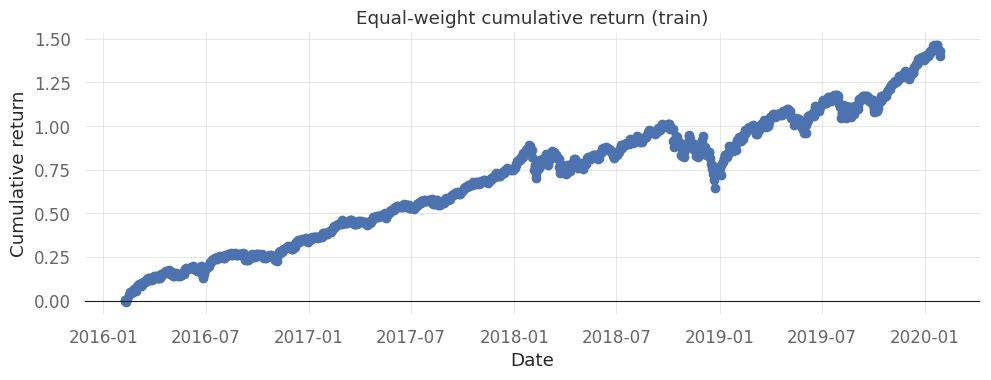

In [17]:
values = np.asarray(ew_train_env._asset_memory["final"], dtype=float)
dates = pd.to_datetime(ew_train_env._date_memory)
cumulative = values / values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (train)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


Equal-weight cumulative return on the training window.


In [18]:
ew_test_env = make_env(test)

rewards = equal_weight_portfolio(ew_test_env)

Initial portfolio value:10000
Final portfolio value: 11404.853515625
Final accumulative portfolio value: 1.140485405921936
Maximum DrawDown: -0.33445477539516255
Sharpe ratio: 0.619206151389339
Mean ex-ante daily vol: 0.019679318734421844
Mean deviation from equal weight: 1.2982072251164414e-07


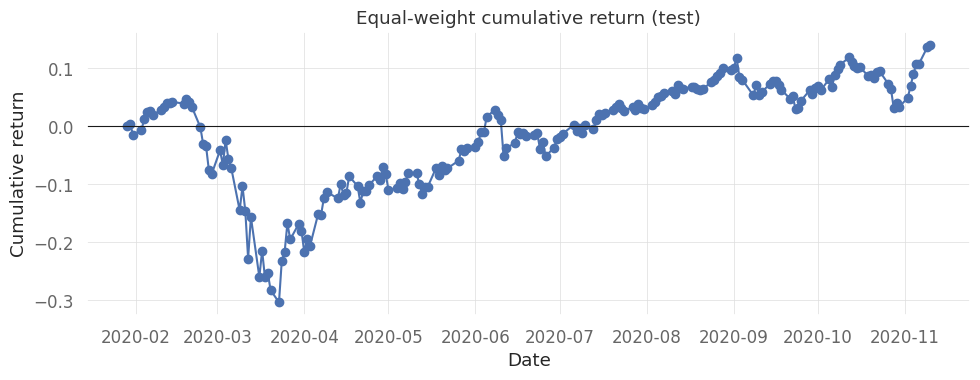

In [19]:
ew_values = np.asarray(ew_test_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_test_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(ew_dates, ew_cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()


## PPO


In [20]:
# Testing First RL Model
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [21]:
train.describe()

,close,volume,rsi_6,stochrsi_3,boll_ub,boll_lb,boll_pctb,volume_stad,rsi_6_scale,stochrsi_3_scale,...,macd_signal,rsi_signal,adx_signal,cci_signal,boll_signal,macd_signal_held,rsi_signal_held,adx_signal_held,cci_signal_held,boll_signal_held
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,105.603823,1.709480e+07,55.137679,53.221203,109.674209,100.119740,0.584210,-0.005429,0.551377,0.532212,...,0.013220,0.12388,0.136030,0.120150,-0.027750,0.034360,0.062550,0.216150,0.226170,-0.175460
std,128.494826,5.321843e+07,18.181717,45.994281,134.098385,121.571233,0.318908,1.013613,0.181817,0.459943,...,0.726396,0.73839,0.690355,0.613936,0.327934,0.999415,0.998012,0.976278,0.971219,0.977161
min,0.805635,0.000000e+00,2.740368,0.000000,0.966040,0.745756,-0.520502,-2.684358,0.027404,0.000000,...,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,41.828529,2.317971e+06,42.129866,0.000000,43.319358,39.696012,0.336355,-0.733837,0.421299,0.000000,...,-1.000000,0.00000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,72.326136,4.710799e+06,56.040377,63.574245,75.156793,68.767533,0.639018,-0.225627,0.560404,0.635742,...,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-1.000000
75%,136.780297,1.275962e+07,68.855087,100.000000,141.123178,130.879172,0.833349,0.573435,0.688551,1.000000,...,1.000000,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1425.671411,2.828708e+09,98.464437,100.000000,1487.008412,1348.127306,1.558492,2.842324,0.984644,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
ppo_train_env = make_env(train)

In [23]:
obs, info = ppo_train_env.reset()
state = obs["state"] if isinstance(obs, dict) else obs

print(ppo_train_env.observation_space)
print("state", state.shape, state.dtype)
print("features", ppo_train_env._features)
print("date", info["end_time"])

frame = pd.DataFrame(
    state[:, :, -1],
    index=ppo_train_env._features,
    columns=list(ppo_train_env._tic_list),
).T
print(frame.describe().T)
print(frame.iloc[:5, :5])
print("nan", np.isnan(state).sum(), "inf", np.isinf(state).sum())


Dict('last_action': Box(0.0, 1.0, (101,), float32), 'state': Box(-inf, inf, (10, 100, 1), float32))
state (10, 100, 1) float32
features ['boll_pctb', 'volume_stad', 'rsi_6_scale', 'macd_stad', 'macds_stad', 'adx_scale', 'pvo_stad', 'tema_stad', 'stochrsi_3_scale', 'log-ret_stad']
date 2016-02-08 00:00:00
                  count      mean       std       min       25%       50%  \
boll_pctb         100.0  0.298411  0.319344 -0.133875  0.018599  0.210178   
volume_stad       100.0  0.634905  0.857512 -0.942026  0.010370  0.553605   
rsi_6_scale       100.0  0.397119  0.219301  0.090091  0.212952  0.337643   
macd_stad         100.0 -0.905407  1.450856 -2.755324 -2.135118 -1.484011   
macds_stad        100.0 -0.432230  1.531547 -2.691451 -1.933571 -0.561479   
adx_scale         100.0  0.302082  0.309493  0.000000  0.000000  0.238757   
pvo_stad          100.0  0.020609  0.038741 -0.068966 -0.004018  0.017077   
tema_stad         100.0 -0.834150  1.249262 -2.600590 -1.845789 -1.229988   
s

In [24]:
import optuna
from stable_baselines3.common.vec_env import VecNormalize

from pathlib import Path
from stable_baselines3.common.logger import configure
from stable_baselines3.common.vec_env import VecMonitor

def trial_logger(algo, trial):
    """CSV + TensorBoard logger at logs/<algo>/trial_<n>, one folder per Optuna trial."""
    path = Path("logs") / algo / f"trial_{trial.number:02d}"
    return str(path), configure(str(path), ["csv", "tensorboard"])

def attach_final_metrics(trial, log_dir):
    """Store the last value of every train/ and rollout/ metric on the Optuna trial."""
    prog = pd.read_csv(Path(log_dir) / "progress.csv")
    for col in prog.columns:
        if col.startswith(("train/", "rollout/")) and prog[col].notna().any():
            trial.set_user_attr(col, float(prog[col].dropna().iloc[-1]))

def plot_training_curves(algo, metrics):
    """One panel per metric, one line per trial, from logs/<algo>/trial_*/progress.csv."""
    runs = {}
    for f in sorted(Path("logs", algo).glob("trial_*/progress.csv")):
        try:
            runs[f.parent.name] = pd.read_csv(f)
        except pd.errors.EmptyDataError:
            pass
    metrics = [m for m in metrics if any(m in d.columns for d in runs.values())]
    if not metrics:
        print("No metrics logged yet under", Path("logs", algo)); return
    ncol = 2
    nrow = (len(metrics) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow), squeeze=False)
    for ax, m in zip(axes.flat, metrics):
        for name, d in runs.items():
            if m in d.columns and d[m].notna().any():
                sub = d[["time/total_timesteps", m]].dropna()
                ax.plot(sub["time/total_timesteps"], sub[m], marker=".", lw=1, label=name)
        ax.set_title(m); ax.set_xlabel("timesteps"); ax.grid(True, alpha=0.3)
    for ax in list(axes.flat)[len(metrics):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=7, ncol=2)
    fig.suptitle(f"{algo.upper()} training metrics per Optuna trial")
    fig.tight_layout(); plt.show()

import shutil

def rollout_value(model, env):
    """Final portfolio value of a deterministic run of `model` on an existing env."""
    vec_env, obs = env.get_sb_env()   # get_sb_env resets the env
    value = float(env._initial_amount)
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done[0]:
            break
        value = float(env._portfolio_value)
    return value

def ppo_vec_env(env, gamma):
    vec_env, _ = env.get_sb_env()
    vec_env = VecMonitor(vec_env)  # adds rollout/ep_rew_mean, ep_len_mean
    return VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)

def build_ppo(params, vec_env):
    return PPO(
        "MultiInputPolicy",
        vec_env,
        verbose=0,
        seed=42,
        n_steps=params["n_steps"],
        batch_size=params["batch_size"],
        clip_range=params["clip_range"],
        gamma=params["gamma"],
        device="cpu",
        learning_rate=params["learning_rate"],
        policy_kwargs=dict(log_std_init=params["log_std_init"]),
    )

# Envs built once and reused by every trial (each run starts with a reset)
ppo_tune_env = make_env(tune_train, ew_penalty=EW_PENALTY, save_plots=False)
ppo_eval_env = make_env(tune_train, save_plots=False)

def objective_ppo(trial):
    params = dict(
        n_steps=trial.suggest_categorical("n_steps", [512, 1024, 2048]),
        batch_size=trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        gamma=trial.suggest_float("gamma", 0.9, 0.999),
        clip_range=trial.suggest_float("clip_range", 0.1, 0.3),
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        log_std_init=trial.suggest_float("log_std_init", -2.0, -1.0),  # the temperature scales exploration too
    )
    model = build_ppo(params, ppo_vec_env(ppo_tune_env, params["gamma"]))
    log_dir, logger = trial_logger("ppo", trial)
    model.set_logger(logger)
    model.learn(total_timesteps=TOTAL_TIMESTEPS, log_interval=1)
    attach_final_metrics(trial, log_dir)
    return rollout_value(model, ppo_eval_env)

shutil.rmtree(Path("logs", "ppo"), ignore_errors=True)  # drop logs of earlier studies
study_ppo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=2))
study_ppo.optimize(objective_ppo, n_trials=N_TRIALS)
print("best PPO params:", study_ppo.best_params, "tuning score:", study_ppo.best_value)

# Retrain the best settings once on all assets (the test cells need the full asset set)
ppo_full_env = make_env(train, ew_penalty=EW_PENALTY, save_plots=False)
model_ppo = build_ppo(study_ppo.best_params, ppo_vec_env(ppo_full_env, study_ppo.best_params["gamma"]))
model_ppo.set_logger(configure("logs/ppo/final", ["csv", "tensorboard"]))
model_ppo.learn(total_timesteps=TOTAL_TIMESTEPS, log_interval=1)
model_ppo.save("ppo_portfolio")
print("final PPO train value:", rollout_value(model_ppo, make_env(train)))

[I 2026-09-26 05:53:39,633] A new study created in memory with name: no-name-dc5f66b8-178f-4c3e-ad78-a37299c3eec3
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 16116.962890625
Final accumulative portfolio value: 1.6116962432861328
Maximum DrawDown: -0.20167081328547565
Sharpe ratio: 0.978633836739238
Mean ex-ante daily vol: 0.0074194759496799345
Mean deviation from equal weight: 0.1937877239763841
Initial portfolio value:10000
Final portfolio value: 15519.7734375
Final accumulative portfolio value: 1.5519773960113525
Maximum DrawDown: -0.1792904496954839
Sharpe ratio: 0.9146326531447275
Mean ex-ante daily vol: 0.007439299020858787
Mean deviation from equal weight: 0.1947256116314832
Initial portfolio value:10000
Final portfolio value: 15081.6083984375
Final accumulative portfolio value: 1.5081608295440674
Maximum DrawDown: -0.21770898433724328
Sharpe ratio: 0.8604504316675059
Mean ex-ante daily vol: 0.0074000442229257635
Mean deviation from equal weight: 0.1950072923217287
Initial portfolio value:10000
Final portfolio value: 15902.728515625
Final accumulative portfolio value: 1.590272903442

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
[I 2026-09-26 05:54:00,522] Trial 0 finished with value: 25387.662109375 and parameters: {'n_steps': 1024, 'batch_size': 64, 'gamma': 0.9857514384317185, 'clip_range': 0.22022300234864176, 'learning_rate': 0.0002607024758370766, 'log_std_init': -1.9794155057041976}. Best is trial 0 with value: 25387.662109375.


Initial portfolio value:10000
Final portfolio value: 25387.662109375
Final accumulative portfolio value: 2.5387661457061768
Maximum DrawDown: -0.14840014890513065
Sharpe ratio: 1.875131441243282
Mean ex-ante daily vol: 0.0073718471700275545
Mean deviation from equal weight: 0.10992578504585951


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

Initial portfolio value:10000
Final portfolio value: 26875.14453125
Final accumulative portfolio value: 2.687514543533325
Maximum DrawDown: -0.15287027932300912
Sharpe ratio: 1.806989903255807
Mean ex-ante daily vol: 0.008113836566251899
Mean deviation from equal weight: 0.3438328960307484
best PPO params: {'n_steps': 512, 'batch_size': 128, 'gamma': 0.9093019215727464, 'clip_range': 0.15377025589818102, 'learning_rate': 0.0008309322947239253, 'log_std_init': -1.0688029923352453} tuning score: 26875.14453125


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 5847.984375
Final accumulative portfolio value: 0.5847984552383423
Maximum DrawDown: -0.4931854838636628
Sharpe ratio: -0.8862305287312627
Mean ex-ante daily vol: 0.007810824265382692
Mean deviation from equal weight: 0.5313326992997124
Initial portfolio value:10000
Final portfolio value: 7502.6298828125
Final accumulative portfolio value: 0.750262975692749
Maximum DrawDown: -0.39643420021227727
Sharpe ratio: -0.46349923655636227
Mean ex-ante daily vol: 0.007840944219460133
Mean deviation from equal weight: 0.5394606530882551
Initial portfolio value:10000
Final portfolio value: 6928.7255859375
Final accumulative portfolio value: 0.6928725838661194
Maximum DrawDown: -0.4158080121676082
Sharpe ratio: -0.6292818522407775
Mean ex-ante daily vol: 0.007812614482201212
Mean deviation from equal weight: 0.5459474521647297
Initial portfolio value:10000
Final portfolio value: 7009.74755859375
Final accumulative portfolio value: 0.7009747624397

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 18463.7890625
Final accumulative portfolio value: 1.8463789224624634
Maximum DrawDown: -0.21225719953287137
Sharpe ratio: 1.1991362507457621
Mean ex-ante daily vol: 0.007705354013698955
Mean deviation from equal weight: 0.3958362067786064
final PPO train value: 18463.7890625


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_clip_range,params_gamma,params_learning_rate,params_log_std_init,...,train/entropy_loss,train/explained_variance,train/learning_rate,train/loss,train/n_updates,train/policy_gradient_loss,train/std,train/value_loss,system_attrs_tpe:relative_params:0,state
4,4,26875.144531,2026-09-26 05:54:46.008787,2026-09-26 05:55:04.770252,0 days 00:00:18.761465,128,0.153770,0.909302,0.000831,-1.068803,...,-7.835932,-0.087200,0.000831,0.172758,390.0,-0.091772,0.327010,1.032900,"{""batch_size"": 128, ""clip_range"": 0.1537702558...",COMPLETE
1,1,26348.830078,2026-09-26 05:54:00.523006,2026-09-26 05:54:15.382036,0 days 00:00:14.859030,512,0.158246,0.942763,0.000167,-1.860506,...,11.633629,0.070054,0.000167,0.304123,390.0,-0.052404,0.154683,0.836848,NaN,COMPLETE
0,0,25387.662109,2026-09-26 05:53:39.634115,2026-09-26 05:54:00.522476,0 days 00:00:20.888361,64,0.220223,0.985751,0.000261,-1.979416,...,15.182094,0.649243,0.000261,-0.152959,190.0,-0.126139,0.134891,0.110247,NaN,COMPLETE
2,2,25380.830078,2026-09-26 05:54:15.382571,2026-09-26 05:54:31.759226,0 days 00:00:16.376655,512,0.189719,0.950787,0.000049,-1.836156,...,10.889720,-0.049728,0.000049,0.326628,390.0,-0.023944,0.159170,0.781724,"{""batch_size"": 512, ""clip_range"": 0.1897189137...",COMPLETE
3,3,25322.789062,2026-09-26 05:54:31.760145,2026-09-26 05:54:46.007951,0 days 00:00:14.247806,512,0.261492,0.974994,0.000014,-1.062832,...,-9.258223,-0.594282,0.000014,0.305080,90.0,-0.006405,0.345461,0.724047,"{""batch_size"": 512, ""clip_range"": 0.2614916629...",COMPLETE


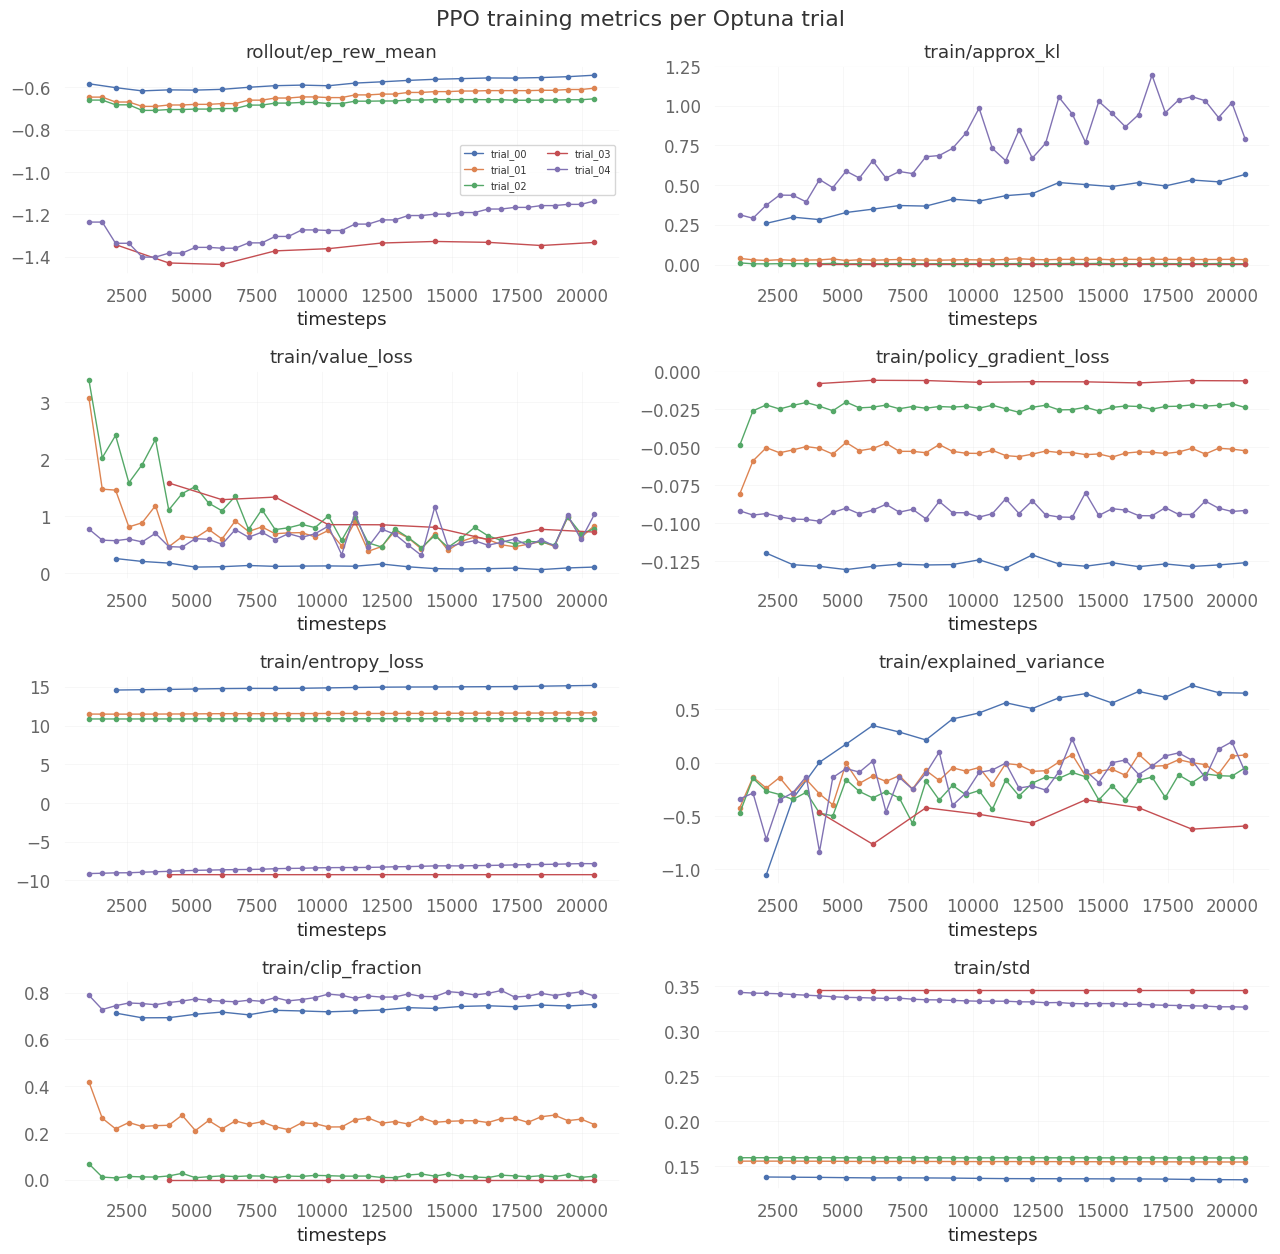

In [25]:
# Per-trial PPO diagnostics: score, params and last logged training metrics
# (all curves also viewable with: tensorboard --logdir logs)
ppo_trials = study_ppo.trials_dataframe()
ppo_trials.columns = [c.replace("user_attrs_", "") for c in ppo_trials.columns]
display(ppo_trials.sort_values("value", ascending=False))

plot_training_curves("ppo", [
    "rollout/ep_rew_mean", "train/approx_kl", "train/value_loss", "train/policy_gradient_loss",
    "train/entropy_loss", "train/explained_variance", "train/clip_fraction", "train/std",
])

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 10113.982421875
Final accumulative portfolio value: 1.011398196220398
Maximum DrawDown: -0.32666752363975426
Sharpe ratio: 0.22866850427548355
Mean ex-ante daily vol: 0.01903822998473976
Mean deviation from equal weight: 0.3897385389272865


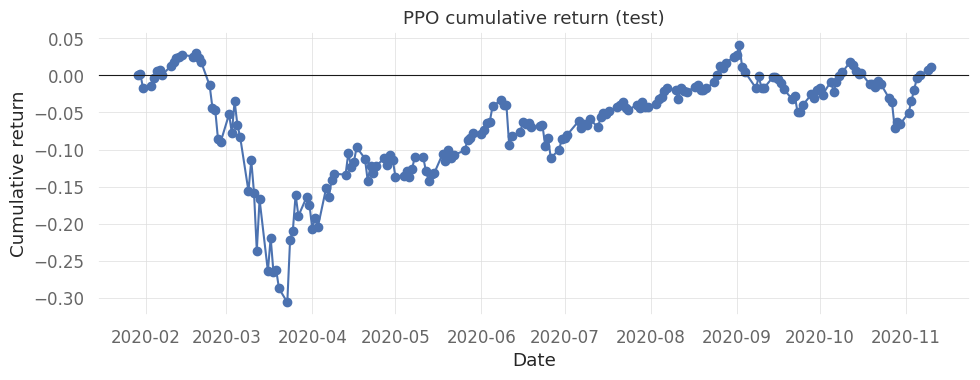

In [26]:
ppo_test_env = make_env(test)
env_test, obs = ppo_test_env.get_sb_env()

values, dates = (
    list(ppo_test_env._asset_memory["final"]),
    list(ppo_test_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_test_env._asset_memory["final"])
    dates = list(ppo_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("PPO cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 11180.51953125
Final accumulative portfolio value: 1.1180520057678223
Maximum DrawDown: -0.16176571205612644
Sharpe ratio: 0.495097456812496
Mean ex-ante daily vol: 0.007657434684979738
Mean deviation from equal weight: 0.38952940479640913
Initial portfolio value:10000
Final portfolio value: 14276.3203125
Final accumulative portfolio value: 1.4276319742202759
Maximum DrawDown: -0.1508652387898337
Sharpe ratio: 1.4029166000133648
Mean ex-ante daily vol: 0.007342980269218084
Mean deviation from equal weight: 1.2982072251164414e-07


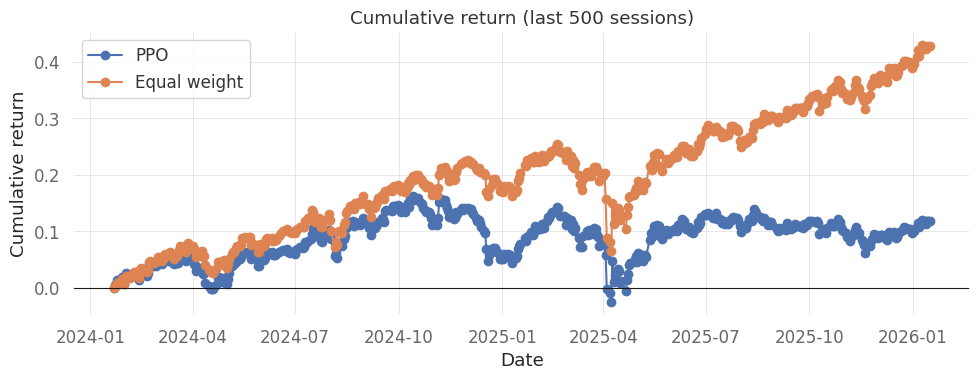

In [27]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]
recent = pd.DataFrame(recent).reset_index()
ppo_recent_env = make_env(recent)
env_test, obs = ppo_recent_env.get_sb_env()

values, dates = (
    list(ppo_recent_env._asset_memory["final"]),
    list(ppo_recent_env._date_memory),
)
while True:
    action, _ = model_ppo.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ppo_recent_env._asset_memory["final"])
    dates = list(ppo_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = make_env(recent)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="PPO")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()

## DDPG


In [28]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import VecNormalize
import optuna

def ddpg_vec_env(env, gamma):
    vec_env, _ = env.get_sb_env()
    vec_env = VecMonitor(vec_env)  # adds rollout/ep_rew_mean, ep_len_mean
    return VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0, gamma=gamma)

def build_ddpg(params, env):
    n_actions = env.action_space.shape[-1]
    return DDPG(
        "MultiInputPolicy",
        ddpg_vec_env(env, params["gamma"]),
        verbose=0,
        seed=42,
        learning_rate=params["learning_rate"],
        buffer_size=100_000,
        learning_starts=params["learning_starts"],
        tau=params["tau"],
        gamma=params["gamma"],
        train_freq=1,
        gradient_steps=1,
        batch_size=params["batch_size"],
        device="cuda",
        action_noise=NormalActionNoise(
            mean=np.zeros(n_actions), sigma=params["sigma"] * np.ones(n_actions)
        ),
    )

# Envs built once and reused by every trial (each run starts with a reset)
ddpg_tune_env = make_env(tune_train, ew_penalty=EW_PENALTY, save_plots=False)
ddpg_eval_env = make_env(tune_train, save_plots=False)

def objective_ddpg(trial):
    params = dict(
        gamma=trial.suggest_float("gamma", 0.95, 0.999),
        sigma=trial.suggest_float("sigma", 0.05, 0.2),
        learning_rate=trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        learning_starts=trial.suggest_categorical("learning_starts", [500, 1000, 2000]),
        tau=trial.suggest_float("tau", 1e-3, 1e-2, log=True),
        batch_size=trial.suggest_categorical("batch_size", [64, 128, 256]),
    )
    model = build_ddpg(params, ddpg_tune_env)
    log_dir, logger = trial_logger("ddpg", trial)
    model.set_logger(logger)
    model.learn(total_timesteps=TOTAL_TIMESTEPS, log_interval=1)  # dump every episode
    attach_final_metrics(trial, log_dir)
    return rollout_value(model, ddpg_eval_env)

shutil.rmtree(Path("logs", "ddpg"), ignore_errors=True)  # drop logs of earlier studies
study_ddpg = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=2))
study_ddpg.optimize(objective_ddpg, n_trials=N_TRIALS)
print("best DDPG params:", study_ddpg.best_params, "tuning score:", study_ddpg.best_value)

# Retrain the best settings once on all assets (the test cells need the full asset set)
ddpg_full_env = make_env(train, ew_penalty=EW_PENALTY, save_plots=False)
model_ddpg = build_ddpg(study_ddpg.best_params, ddpg_full_env)
model_ddpg.set_logger(configure("logs/ddpg/final", ["csv", "tensorboard"]))
model_ddpg.learn(total_timesteps=TOTAL_TIMESTEPS, log_interval=1)
model_ddpg.save("ddpg_portfolio")
print("final DDPG train value:", rollout_value(model_ddpg, make_env(train)))

[I 2026-09-26 05:55:36,336] A new study created in memory with name: no-name-71a1757d-5f56-4ce9-994f-d760a640aa01
/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 9669.6826171875
Final accumulative portfolio value: 0.9669682383537292
Maximum DrawDown: -0.3304801458714569
Sharpe ratio: 0.0016266772673988773
Mean ex-ante daily vol: 0.007443817564142945
Mean deviation from equal weight: 0.49541532312433045
Initial portfolio value:10000
Final portfolio value: 16639.513671875
Final accumulative portfolio value: 1.6639513969421387
Maximum DrawDown: -0.16021220549525939
Sharpe ratio: 1.045566787495617
Mean ex-ante daily vol: 0.007412207519977802
Mean deviation from equal weight: 0.44927032030634245
Initial portfolio value:10000
Final portfolio value: 21151.412109375
Final accumulative portfolio value: 2.1151411533355713
Maximum DrawDown: -0.12029124607895236
Sharpe ratio: 1.5431422384875582
Mean ex-ante daily vol: 0.007255993478381938
Mean deviation from equal weight: 0.5068859623115683
Initial portfolio value:10000
Final portfolio value: 27747.8671875
Final accumulative portfolio value: 2.7747867107

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
[I 2026-09-26 05:57:03,247] Trial 0 finished with value: 457069.3125 and parameters: {'gamma': 0.9683524658235207, 'sigma': 0.19260714596148742, 'learning_rate': 0.000291063591313307, 'learning_starts': 500, 'tau': 0.001143098387631322, 'batch_size': 64}. Best is trial 0 with value: 457069.3125.


Initial portfolio value:10000
Final portfolio value: 457069.3125
Final accumulative portfolio value: 45.706932067871094
Maximum DrawDown: -0.07871367427604248
Sharpe ratio: 6.974276963470449
Mean ex-ante daily vol: 0.007894835217955476
Mean deviation from equal weight: 0.5522791401635513


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


...

Initial portfolio value:10000
Final portfolio value: 44671.59765625
Final accumulative portfolio value: 4.467159748077393
Maximum DrawDown: -0.13414237924922634
Sharpe ratio: 2.726114212002749
Mean ex-ante daily vol: 0.007773885100273839
Mean deviation from equal weight: 0.5594991479608298
best DDPG params: {'gamma': 0.9510086402204943, 'sigma': 0.19548647782429918, 'learning_rate': 0.000462258900102083, 'learning_starts': 500, 'tau': 0.0020148477884158666, 'batch_size': 64} tuning score: 529524.0


/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 11228.3291015625
Final accumulative portfolio value: 1.1228328943252563
Maximum DrawDown: -0.2519982960994631
Sharpe ratio: 0.29455127473452947
Mean ex-ante daily vol: 0.007184994407280854
Mean deviation from equal weight: 0.44008222024265686
Initial portfolio value:10000
Final portfolio value: 17969.03125
Final accumulative portfolio value: 1.796903133392334
Maximum DrawDown: -0.18966802628731316
Sharpe ratio: 1.219730776381318
Mean ex-ante daily vol: 0.007222282312747218
Mean deviation from equal weight: 0.43949625170466505
Initial portfolio value:10000
Final portfolio value: 18238.849609375
Final accumulative portfolio value: 1.8238849639892578
Maximum DrawDown: -0.18574992430930481
Sharpe ratio: 1.2442751659045026
Mean ex-ante daily vol: 0.007228310679226491
Mean deviation from equal weight: 0.4737795050582738
Initial portfolio value:10000
Final portfolio value: 21214.490234375
Final accumulative portfolio value: 2.12144899368286

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 62128.76171875
Final accumulative portfolio value: 6.212876319885254
Maximum DrawDown: -0.12858184263421768
Sharpe ratio: 3.562326055766755
Mean ex-ante daily vol: 0.0073727889620023015
Mean deviation from equal weight: 0.47677686020699156
final DDPG train value: 62128.76171875


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_gamma,params_learning_rate,params_learning_starts,params_sigma,params_tau,rollout/ep_len_mean,rollout/ep_rew_mean,train/actor_loss,train/critic_loss,train/learning_rate,train/n_updates,system_attrs_tpe:relative_params:0,state
1,1,529524.000000,2026-09-26 05:57:03.247809,2026-09-26 05:58:38.535592,0 days 00:01:35.287783,64,0.951009,0.000462,500,0.195486,0.002015,1000.0,1.473945,-2.349648,0.002465,0.000462,19499.0,NaN,COMPLETE
0,0,457069.312500,2026-09-26 05:55:36.337334,2026-09-26 05:57:03.247113,0 days 00:01:26.909779,64,0.968352,0.000291,500,0.192607,0.001143,1000.0,1.206031,-1.323828,0.001393,0.000291,19499.0,NaN,COMPLETE
2,2,360804.625000,2026-09-26 05:58:38.536543,2026-09-26 06:00:13.613964,0 days 00:01:35.077421,64,0.950232,0.000142,500,0.175094,0.001832,1000.0,1.115647,-2.239987,0.001704,0.000142,19499.0,"{""batch_size"": 64, ""gamma"": 0.9502323621858358...",COMPLETE
3,3,276197.250000,2026-09-26 06:00:13.614680,2026-09-26 06:01:48.067679,0 days 00:01:34.452999,64,0.989700,0.000701,500,0.090373,0.004576,1000.0,1.091173,-1.510808,0.000256,0.000701,19499.0,"{""batch_size"": 64, ""gamma"": 0.9896995569204301...",COMPLETE
4,4,44671.597656,2026-09-26 06:01:48.068428,2026-09-26 06:03:25.314912,0 days 00:01:37.246484,64,0.962443,0.000017,500,0.195120,0.008525,1000.0,-0.184881,-2.345219,0.017130,0.000017,19499.0,"{""batch_size"": 64, ""gamma"": 0.9624430562228713...",COMPLETE


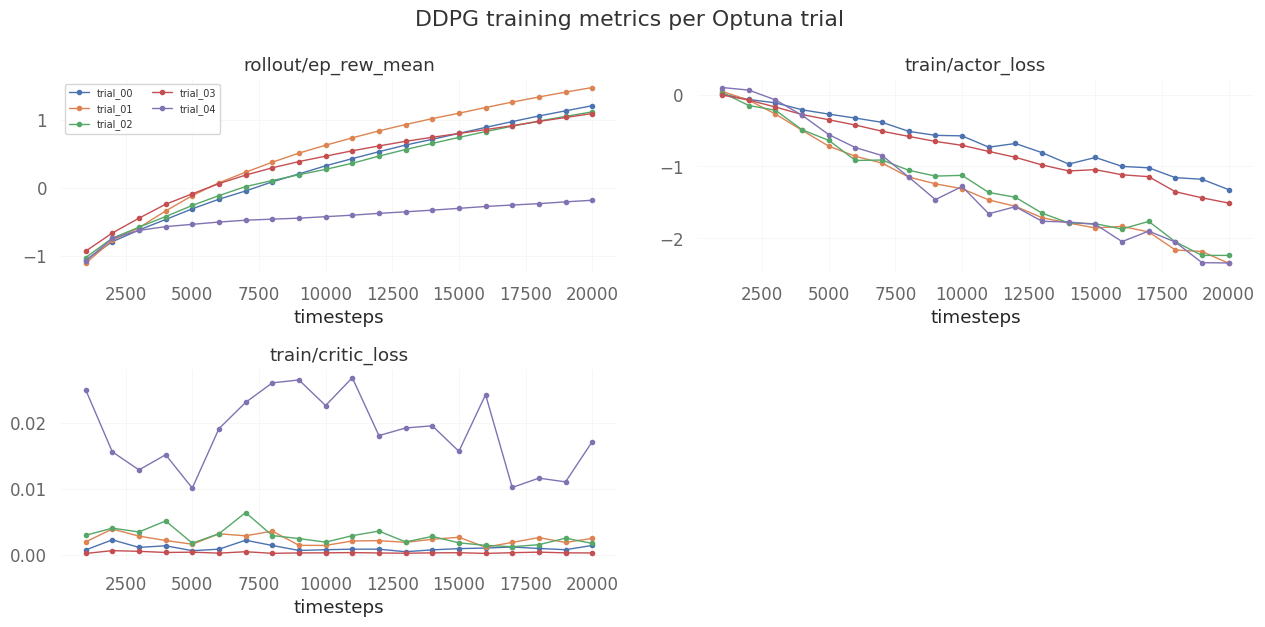

In [29]:
# Per-trial DDPG diagnostics: score, params and last logged actor/critic losses
ddpg_trials = study_ddpg.trials_dataframe()
ddpg_trials.columns = [c.replace("user_attrs_", "") for c in ddpg_trials.columns]
display(ddpg_trials.sort_values("value", ascending=False))

plot_training_curves("ddpg", ["rollout/ep_rew_mean", "train/actor_loss", "train/critic_loss"])

In [30]:
def test_function(model, df, title):
    env = make_env(df)

    env_test, obs = env.get_sb_env()
    values, dates = (
        list(env._asset_memory["final"]),
        list(env._date_memory),
    )
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env_test.step(action)
        if done[0]:
            break
        values = list(env._asset_memory["final"])
        dates = list(env._date_memory)
    
    values = np.asarray(values, dtype=float)
    dates = pd.to_datetime(dates)
    cumulative = values / values[0] - 1

    plt.figure(figsize=(10, 4))
    plt.plot(dates, cumulative, marker="o")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative return")
    plt.tight_layout()
    plt.show()

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 11033.521484375
Final accumulative portfolio value: 1.1033521890640259
Maximum DrawDown: -0.3172812817398074
Sharpe ratio: 0.5119240995204879
Mean ex-ante daily vol: 0.019412403218417862
Mean deviation from equal weight: 0.49359938748784704


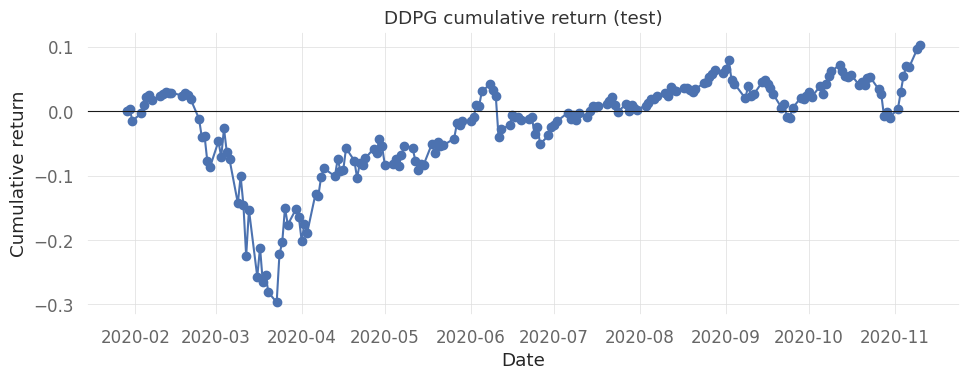

In [31]:
ddpg_test_env = make_env(test)
env_test, obs = ddpg_test_env.get_sb_env()

values, dates = (
    list(ddpg_test_env._asset_memory["final"]),
    list(ddpg_test_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_test_env._asset_memory["final"])
    dates = list(ddpg_test_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("DDPG cumulative return (test)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()

/home/ashu/ml_env/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Initial portfolio value:10000
Final portfolio value: 11425.552734375
Final accumulative portfolio value: 1.1425552368164062
Maximum DrawDown: -0.18205704614628027
Sharpe ratio: 0.5440440755416317
Mean ex-ante daily vol: 0.007422630433726653
Mean deviation from equal weight: 0.49430541887532775
Initial portfolio value:10000
Final portfolio value: 14276.3203125
Final accumulative portfolio value: 1.4276319742202759
Maximum DrawDown: -0.1508652387898337
Sharpe ratio: 1.4029166000133648
Mean ex-ante daily vol: 0.007342980269218084
Mean deviation from equal weight: 1.2982072251164414e-07


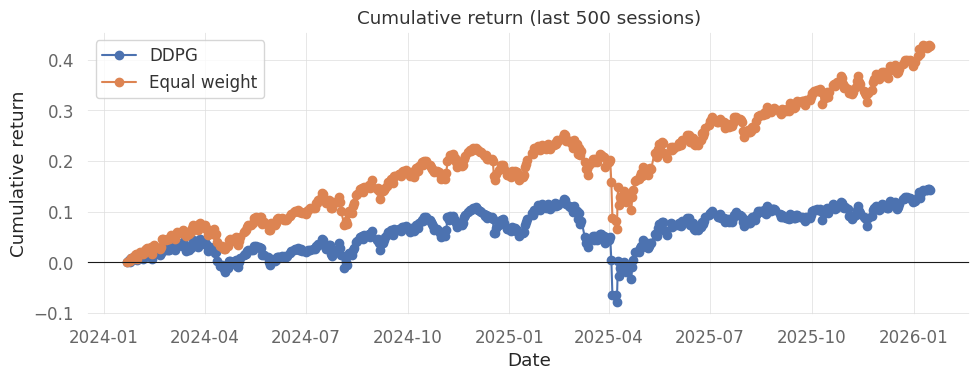

In [32]:
sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
recent = features[pd.to_datetime(features["date"]).isin(sessions[-500:])]
recent = pd.DataFrame(recent).reset_index()

ddpg_recent_env = make_env(recent)
env_test, obs = ddpg_recent_env.get_sb_env()

values, dates = (
    list(ddpg_recent_env._asset_memory["final"]),
    list(ddpg_recent_env._date_memory),
)
while True:
    action, _ = model_ddpg.predict(obs, deterministic=True)
    obs, reward, done, info = env_test.step(action)
    if done[0]:
        break
    values = list(ddpg_recent_env._asset_memory["final"])
    dates = list(ddpg_recent_env._date_memory)
values = np.asarray(values, dtype=float)
dates = pd.to_datetime(dates)
cumulative = values / values[0] - 1

ew_recent_env = make_env(recent)
_ = equal_weight_portfolio(ew_recent_env)
ew_values = np.asarray(ew_recent_env._asset_memory["final"], dtype=float)
ew_dates = pd.to_datetime(ew_recent_env._date_memory)
ew_cumulative = ew_values / ew_values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o", label="DDPG")
plt.plot(ew_dates, ew_cumulative, marker="o", label="Equal weight")
plt.axhline(0, color="k", lw=0.8)
plt.title("Cumulative return (last 500 sessions)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.show()

## Strategy comparison


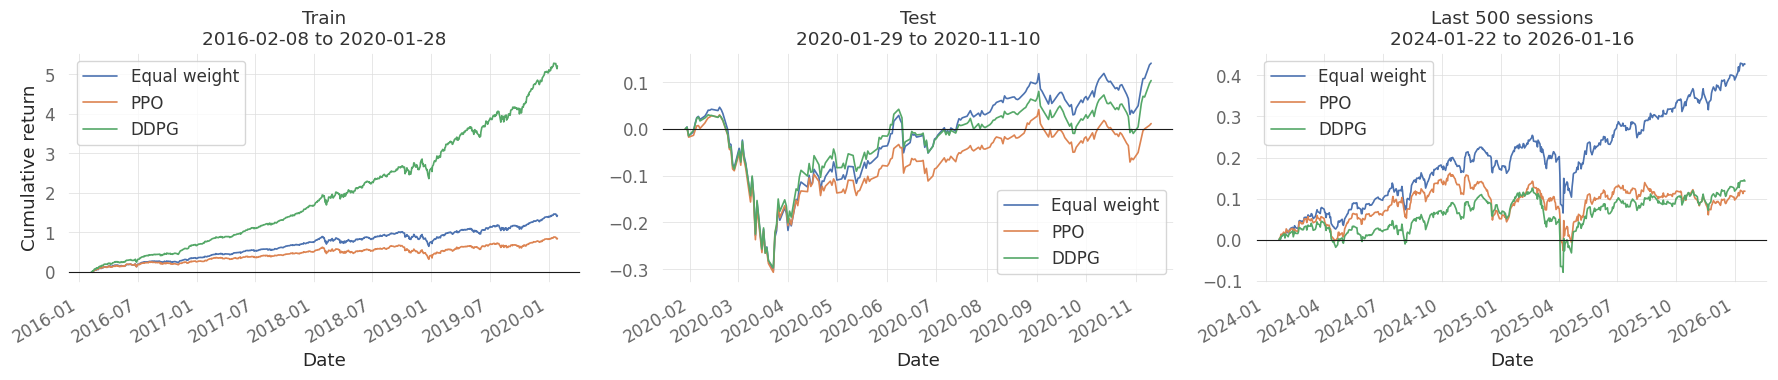

final value  total return  Sharpe  \
window            strategy                                          
Train             Equal weight   24284.3164        1.4284  1.7901   
                  PPO            18463.7891        0.8464  1.1997   
                  DDPG           62128.7617        5.2129  3.5642   
Test              Equal weight   11404.2246        0.1404  0.6206   
                  PPO            10113.9824        0.0114  0.2292   
                  DDPG           11033.5215        0.1034  0.5132   
Last 500 sessions Equal weight   14274.3252        0.4274  1.4038   
                  PPO            11180.5195        0.1181  0.4956   
                  DDPG           11425.5527        0.1426  0.5446   

                                max drawdown  daily turnover  \
window            strategy                                     
Train             Equal weight       -0.1831          0.0042   
                  PPO                -0.2123          0.2637   
                  DDPG               -0.1286          0.2976   
Test              Equal weight       -0.3345          0.0072   
                  PPO                -0.3267          0.2796   
                  DDPG               -0.3173          0.3098   
Last 500 sessions Equal weight       -0.1509          0.0053   
                  PPO                -0.1618          0.2669   
                  DDPG               -0.1821          0.3057   

                                gap to equal weight  
window            strategy                           
Train             Equal weight               0.0000  
                  PPO                        0.3958  
                  DDPG                       0.4768  
Test              Equal weight               0.0000  
                  PPO                        0.3897  
                  DDPG                       0.4936  
Last 500 sessions Equal weight               0.0000  
                  PPO                        0.3895  
                  DDPG                       0.4943

In [33]:
def run_episode(df, model=None):
    """Run one full episode on df, with equal weights when model is None, and return the env.

    Stops before the env's final bookkeeping call, so its memories are still intact.
    """
    env = make_env(df, save_plots=False)
    obs, _ = env.reset()
    ew = np.r_[0.0, np.full(env._stock_dim, 1.0 / env._stock_dim)].astype(np.float32)
    while env._time_index < len(env._sorted_times) - 1:
        action = ew if model is None else model.predict(obs, deterministic=True)[0]
        obs, *_ = env.step(action)
    return env

def episode_metrics(env):
    values = np.asarray(env._asset_memory["final"], dtype=float)
    rets = np.asarray(env._portfolio_return_memory[1:], dtype=float)
    chosen = np.asarray(env._actions_memory[1:], dtype=float)    # weights picked each day
    held = np.asarray(env._final_weights[:-1], dtype=float)      # weights going into that day
    turnover = 0.5 * np.abs(chosen - held).sum(axis=1)
    return {
        "final value": values[-1],
        "total return": values[-1] / values[0] - 1,
        "Sharpe": np.sqrt(252) * rets.mean() / rets.std(ddof=1),
        "max drawdown": (values / np.maximum.accumulate(values) - 1).min(),
        "daily turnover": turnover[1:].mean(),                   # skips the first move out of cash
        "gap to equal weight": float(np.mean(env._ew_deviation_memory[1:])),
    }

sessions = pd.Index(pd.to_datetime(features["date"]).unique()).sort_values()
# filtering the stockstats frame moves "date" into the index; reset_index() brings it back
recent = pd.DataFrame(features[pd.to_datetime(features["date"]).isin(sessions[-500:])]).reset_index()

windows = {"Train": train, "Test": test, "Last 500 sessions": recent}
strategies = {"Equal weight": None, "PPO": model_ppo, "DDPG": model_ddpg}
episodes = {(w, s): run_episode(df, model) for w, df in windows.items() for s, model in strategies.items()}

fig, axes = plt.subplots(1, len(windows), figsize=(18, 4))
for ax, (w, df) in zip(axes, windows.items()):
    for s in strategies:
        env = episodes[(w, s)]
        values = np.asarray(env._asset_memory["final"], dtype=float)
        ax.plot(pd.to_datetime(env._date_memory), values / values[0] - 1, lw=1.2, label=s)
    span = pd.to_datetime(df["date"])
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{w}\n{span.min():%Y-%m-%d} to {span.max():%Y-%m-%d}")
    ax.set_xlabel("Date")
    ax.legend()
axes[0].set_ylabel("Cumulative return")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

metrics = pd.DataFrame({k: episode_metrics(env) for k, env in episodes.items()}).T
metrics.index.names = ["window", "strategy"]
metrics.round(4)